In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [2]:
model_df = pd.read_csv(
    DATA_RAW/"fe_groups/g4.csv"
)

print(model_df.shape)
model_df.head()

(2255, 51)


,Unnamed: 0.1,Unnamed: 0,tconst,primaryTitle,startYear,the_numbers_url,scrape_success,scrape_error,opening_weekend_gross,opening_theaters,...,actor_5,actor_6,director_name,writer_name,actor_1_name,actor_2_name,actor_3_name,g4_local_60d_mode_genre,g4_local_60d_mode_genre_count,g4_matches_local_60d_mode_genre
0,0,1112,tt1311067,Halloween II,2009.0,https://www.the-numbers.com/movie/Halloween-II,True,NaN,7676836.0,1217.0,...,nm3101175,nm0000374,Rob Zombie,Rob Zombie,Scout Taylor-Compton,Tyler Mane,Malcolm McDowell,NaN,0,0
1,1,689,tt0816462,Conan the Barbarian,2011.0,https://www.the-numbers.com/movie/Conan-the-Ba...,True,NaN,9479373.0,1358.0,...,nm0629697,nm1452211,Marcus Nispel,Thomas Dean Donnelly,Jason Momoa,Ron Perlman,Rose McGowan,NaN,0,0
2,2,1974,tt4731008,The Wild Life,2016.0,https://www.the-numbers.com/movie/Wild-Life-The,True,NaN,4001400.0,1140.0,...,nm2521682,nm1064588,Vincent Kesteloot,Daniel Defoe,Matthias Schweighöfer,Kaya Yanar,Ilka Bessin,NaN,0,0
3,3,980,tt1160419,Dune: Part One,2021.0,https://www.the-numbers.com/movie/Dune,True,NaN,6025091.0,915.0,...,nm0597388,nm0001745,Denis Villeneuve,Jon Spaihts,Timothée Chalamet,Rebecca Ferguson,Zendaya,NaN,0,0
4,4,1291,tt1540128,Playing for Keeps,2012.0,https://www.the-numbers.com/movie/Playing-for-...,True,NaN,1406300.0,1148.0,...,nm0000235,nm0001876,Gabriele Muccino,Robbie Fox,Gerard Butler,Jessica Biel,Dennis Quaid,NaN,0,0


In [9]:
target = "log_opening_weekend_gross"

num_group_features = [
    'g4_local_60d_mode_genre_count',
]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + num_group_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

cat_group_feature = [
    'g4_local_60d_mode_genre',
    'g4_matches_local_60d_mode_genre'
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
 ] + people_features + cat_group_feature

In [10]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(2255, 21)
(2255,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
y_test_dollars = np.expm1(y_test)

In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [14]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [15]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

{'model': 'Ridge Baseline',
 'r2_log': 0.6082237554820729,
 'mae_log': 0.8212655253262315,
 'mae_dollars': 14580267.404851617}

In [16]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

{'model': 'XGBoost Baseline',
 'r2_log': 0.6554659441693309,
 'mae_log': 0.7489484026627811,
 'mae_dollars': 11732493.124731496}

In [17]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.608224,0.821266,1.458027e+07
1,XGBoost Baseline,0.655466,0.748948,1.173249e+07


In [18]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [19]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

In [20]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

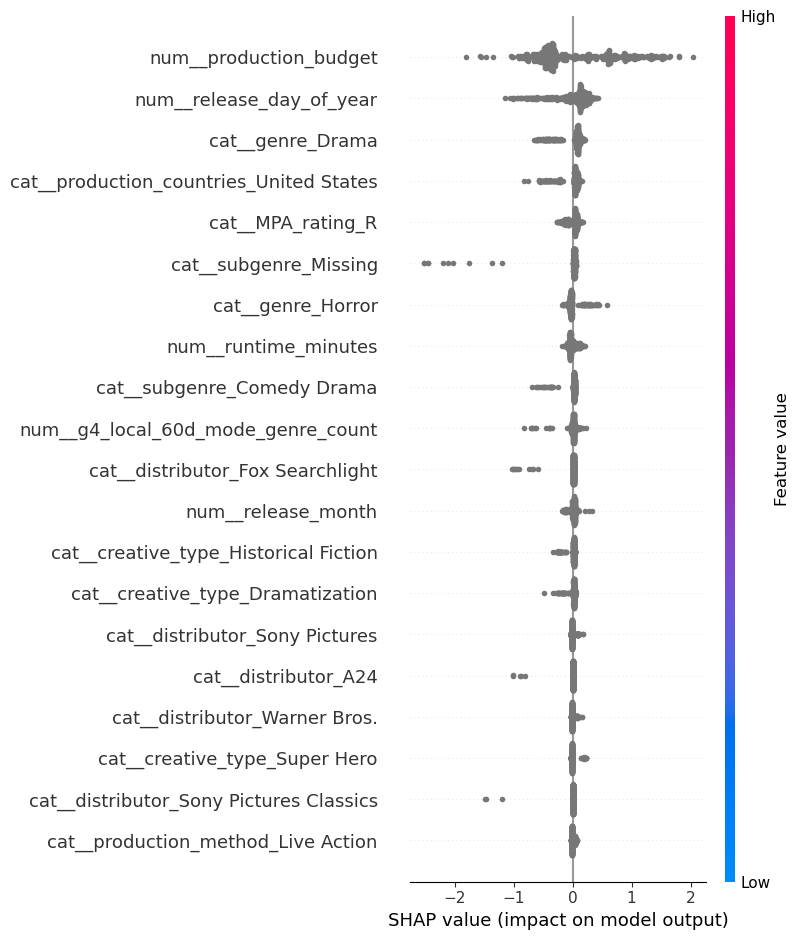

In [21]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

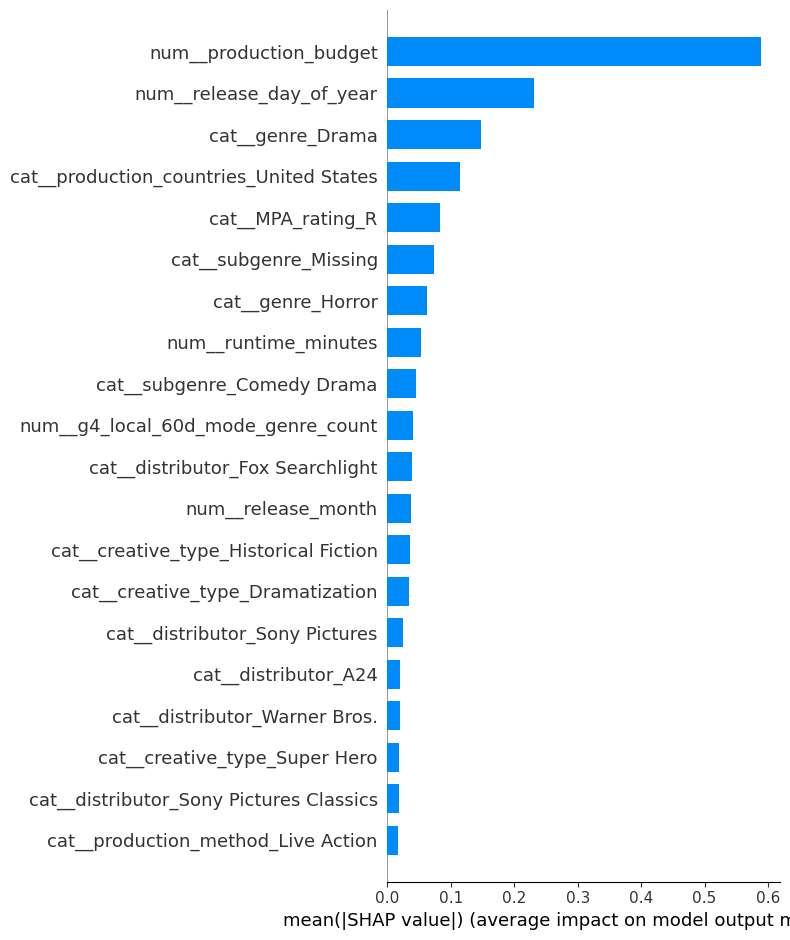

In [22]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [23]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g4_local_60d_mode_genre_count,distributor,MPA_rating,genre,subgenre,source,...,actor_1,actor_2,actor_3,g4_local_60d_mode_genre,g4_matches_local_60d_mode_genre,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
1847,400000000.0,181.0,4,116,8,Walt Disney,PG-13,Action,Action Adventure,Based on Comic/Graphic Novel,...,nm0000375,nm0262635,nm0749263,Adventure,0,19.693568,18.698883,3.571150e+08,132075336.0,2.250397e+08
1718,200000000.0,120.0,2,47,9,Walt Disney,PG-13,Action,Action Adventure,Based on Comic/Graphic Novel,...,nm1569276,nm0430107,nm2143282,Drama,0,19.123798,18.203321,2.020040e+08,80464080.0,1.215399e+08
1620,160000000.0,123.0,3,76,8,Walt Disney,PG,Musical,Family Musical,Based on Folk Tale/Legend/Fairytale,...,nm5177626,nm11380870,nm3592451,Action,0,18.978870,17.811687,1.747506e+08,54389816.0,1.203608e+08
1619,160000000.0,123.0,3,76,8,Walt Disney,PG,Musical,Family Musical,Based on Folk Tale/Legend/Fairytale,...,nm0914612,nm1405398,nm1812656,Action,0,18.978870,17.811687,1.747506e+08,54389816.0,1.203608e+08
2126,145000000.0,114.0,7,202,10,Warner Bros.,PG-13,Comedy,Satirical Comedy,Based on Toy,...,nm3053338,nm0331516,nm4793987,Action,0,18.903243,17.565439,1.620220e+08,42518048.0,1.195040e+08
2204,200000000.0,100.0,6,166,8,Walt Disney,PG,Adventure,Family Adventure,Original Screenplay,...,nm0688132,nm1638321,nm10143485,Action,0,18.853772,17.868338,1.542017e+08,57559952.0,9.664172e+07
1422,74000000.0,91.0,7,191,9,Universal,PG,Adventure,Family Adventure,Spin-Off,...,nm0000113,nm0358316,nm0000474,Action,0,18.566670,17.360123,1.157184e+08,34626252.0,8.109215e+07
1423,74000000.0,91.0,7,191,9,Universal,PG,Adventure,Family Adventure,Spin-Off,...,nm0136797,nm1853544,nm0000273,Action,0,18.566670,17.360123,1.157184e+08,34626252.0,8.109215e+07
203,115000000.0,139.0,5,139,7,20th Century Fox,PG-13,Adventure,Action Adventure,Original Screenplay,...,nm0159789,nm0000204,nm0000191,Comedy,0,18.501669,17.423285,1.084358e+08,36883856.0,7.155199e+07
1832,175000000.0,124.0,3,67,6,Walt Disney,PG-13,Action,Action Adventure,Based on Comic/Graphic Novel,...,nm0488953,nm0000168,nm0578853,Drama,0,18.848777,18.253510,1.534334e+08,84605472.0,6.882795e+07


In [24]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/g4_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/g4_xgb_test_errors.csv",
    index=False
)